Link Video Presentasi: https://drive.google.com/file/d/1Jb9gJ4qlhgPu15M8bOf0w245djqvgTkZ/view?usp=sharing

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor
from torch.utils.data import random_split, DataLoader
from sklearn.metrics import classification_report
from collections import Counter
from torchvision import models

In [2]:
data = datasets.ImageFolder('./dataset') 

print(f"Total ada {len(data)} gambar.")
print("Kelas bencananya:", data.classes)

Total ada 1946 gambar.
Kelas bencananya: ['Earthquake', 'Land_Slide', 'Urban_Fire', 'Water_Disaster']


In [3]:
print("Jumlah gambar per kelas:")
target_counts = Counter(data.targets)
for i, count in target_counts.items():
    print(f"- {data.classes[i]}: {count} gambar")

Jumlah gambar per kelas:
- Earthquake: 36 gambar
- Land_Slide: 456 gambar
- Urban_Fire: 419 gambar
- Water_Disaster: 1035 gambar


In [4]:
def img_stats(root_dir):
    resolutions = []
    ratios = []

    for root, dirs, files in os.walk(root_dir):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                with Image.open(os.path.join(root, file)) as img:
                    w, h = img.size
                    resolutions.append((w, h))
                    ratios.append(w / h)

    widths = [r[0] for r in resolutions]
    heights = [r[1] for r in resolutions]

    print(f"Resolusi rata-rata: {np.mean(widths):.1f} x {np.mean(heights):.1f}")
    print(f"Min resolusi: {min(widths)} x {min(heights)}, Max resolusi: {max(widths)} x {max(heights)}")
    
    print(f"Aspect ratio rata-rata: {np.mean(ratios):.2f}")
    print(f"Min ratio: {min(ratios):.2f}, Max ratio: {max(ratios):.2f}")

img_stats('./dataset')

Resolusi rata-rata: 485.1 x 418.4
Min resolusi: 161 x 119, Max resolusi: 2048 x 1350
Aspect ratio rata-rata: 1.32
Min ratio: 0.51, Max ratio: 3.56


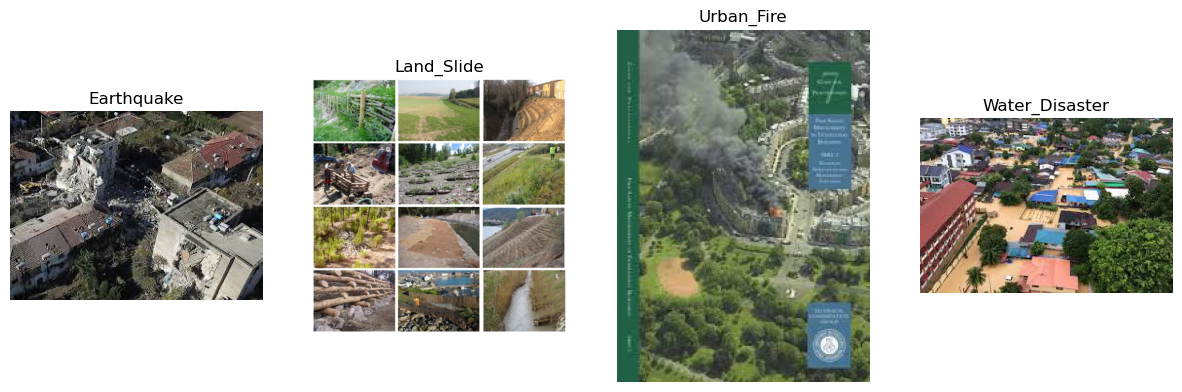

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(15, 5))

for i in range(len(data.classes)):
    idx = data.targets.index(i) 
    
    img, label = data[idx]
    axes[i].imshow(img)
    axes[i].set_title(data.classes[label])
    axes[i].axis('off')

plt.show()

In [6]:
train_transform = transforms.Compose([
    transforms.Resize((227, 227)),
    transforms.RandomHorizontalFlip(p=0.5), 
    transforms.RandomRotation(degrees=15), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [7]:
val_test_transform = transforms.Compose([
    transforms.Resize((227, 227)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [8]:
data_raw = datasets.ImageFolder('./dataset', transform=None)

total_size = len(data_raw)
train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

In [ ]:
generator = torch.Generator().manual_seed(42)
train_raw, val_raw, test_raw = random_split(data_raw, [train_size, val_size, test_size], generator=generator)

class ApplyTransform(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
        
    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y
        
    def __len__(self):
        return len(self.subset)

train_data = ApplyTransform(train_raw, transform=train_transform)
val_data = ApplyTransform(val_raw, transform=val_test_transform)
test_data = ApplyTransform(test_raw, transform=val_test_transform)

train_targets = [data_raw.targets[i] for i in train_raw.indices]

class_sample_count = np.array([train_targets.count(i) for i in range(len(data_raw.classes))])
weight = 1. / class_sample_count
samples_weight = np.array([weight[t] for t in train_targets])
samples_weight = torch.from_numpy(samples_weight).float()

sampler = torch.utils.data.WeightedRandomSampler(weights=samples_weight, num_samples=len(samples_weight), replacement=True)

train_loader = DataLoader(train_data, batch_size=32, sampler=sampler)
val_loader = DataLoader(val_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)
print(f"Data Train: {len(train_data)} gambar")
print(f"Data Val: {len(val_data)} gambar")
print(f"Data Test: {len(test_data)} gambar")

Data Train: 1362 gambar
Data Val: 291 gambar
Data Test: 293 gambar


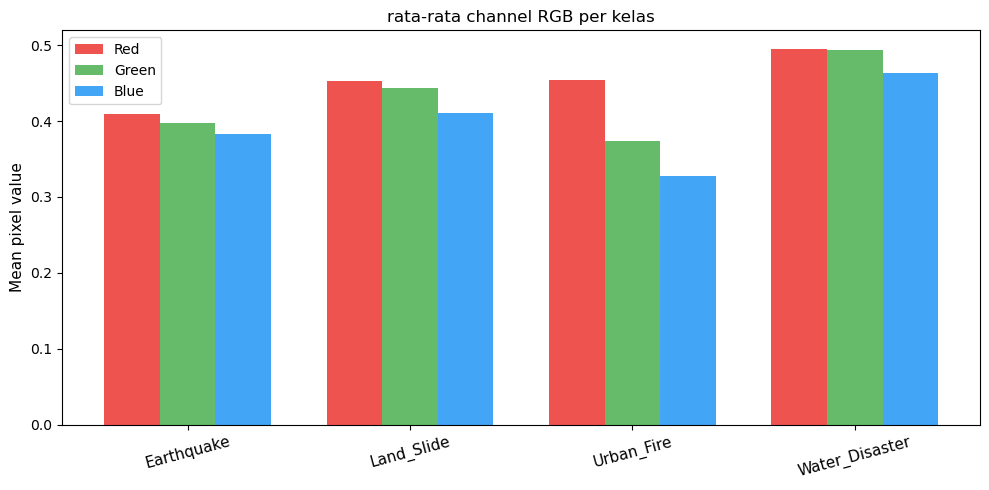

In [10]:
rgb_sums = {i: np.zeros(3) for i in range(len(data.classes))}
class_img_counts = {i: 0 for i in range(len(data.classes))}
to_tensor = ToTensor()

for img_path, label in data.samples:
    img_pil = Image.open(img_path).convert('RGB')
    img_tensor = to_tensor(img_pil)
    rgb_sums[label] += img_tensor.mean(dim=[1, 2]).numpy()
    class_img_counts[label] += 1

rgb_means = {i: rgb_sums[i] / class_img_counts[i] for i in range(len(data.classes))}
labels = data.classes
x = np.arange(len(labels))
width = 0.25

r_means = [rgb_means[i][0] for i in range(len(labels))]
g_means = [rgb_means[i][1] for i in range(len(labels))]
b_means = [rgb_means[i][2] for i in range(len(labels))]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width, r_means, width, label='Red', color='#EF5350')
ax.bar(x, g_means, width, label='Green', color='#66BB6A')
ax.bar(x + width, b_means, width, label='Blue', color='#42A5F5')
ax.set_title('rata-rata channel RGB per kelas')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, fontsize=11)
ax.set_ylabel('Mean pixel value', fontsize=11)
ax.legend()
plt.tight_layout()
plt.show()

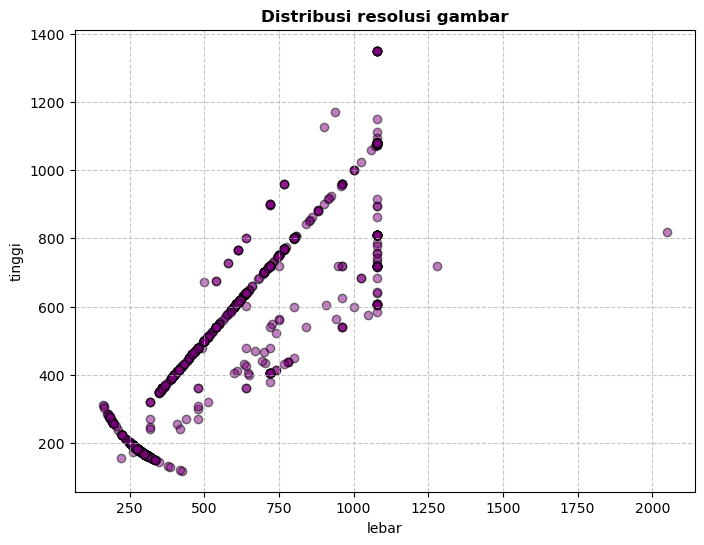

In [11]:
sizes = [Image.open(path).size for path, _ in data.samples]
widths, heights = zip(*sizes)

plt.figure(figsize=(8, 6))
plt.scatter(widths, heights, alpha=0.5, color='purple', edgecolor='black')
plt.title('Distribusi resolusi gambar', fontweight='bold')
plt.xlabel('lebar')
plt.ylabel('tinggi')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

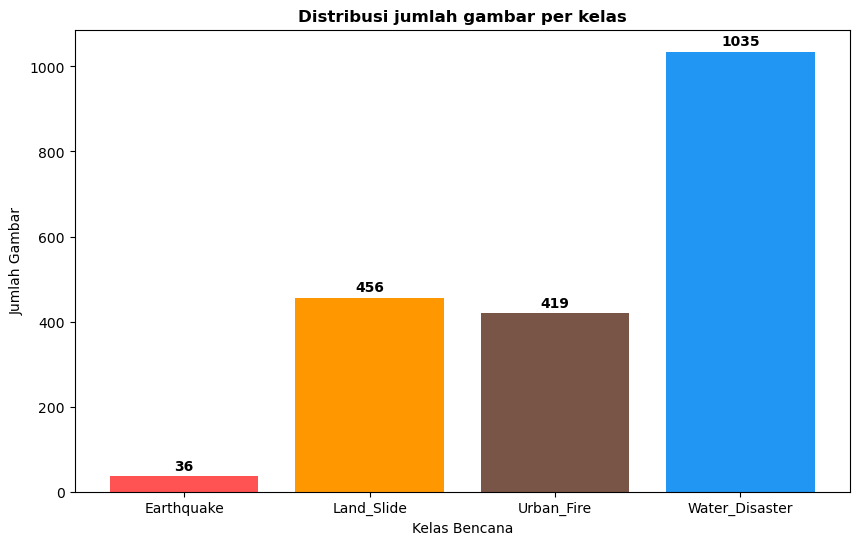

In [12]:
plt.figure(figsize=(10, 6))
classes = data.classes
counts = [target_counts[i] for i in range(len(classes))]
bars = plt.bar(classes, counts, color=['#FF5252', '#FF9800', '#795548', '#2196F3'])
plt.title('Distribusi jumlah gambar per kelas', fontweight='bold')
plt.xlabel('Kelas Bencana')
plt.ylabel('Jumlah Gambar')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 15, int(yval), ha='center', fontweight='bold')
plt.show()

In [13]:
class model1(nn.Module):
    def __init__(self, num_classes=4):
        super(model1, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.conv4 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(128)
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.fc1 = nn.Linear(128 * 14 * 14, 350)
        self.dropout = nn.Dropout(0.5) 
        self.fc2 = nn.Linear(350, num_classes) 

    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))
        x = self.pool4(F.relu(self.bn4(self.conv4(x))))
        
        x = x.view(x.size(0), -1)
        
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model_scratch = model1(num_classes=len(data_raw.classes))

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_scratch = model_scratch.to(device)

criterion = nn.CrossEntropyLoss()
optimizer_scratch = optim.Adam(model_scratch.parameters(), lr=0.001)

scheduler_scratch = optim.lr_scheduler.StepLR(optimizer_scratch, step_size=5, gamma=0.1)

epochs = 15
train_losses, val_losses, train_accs, val_accs = [], [], [], []

print(f"Total parameter model 1: {count_parameters(model_scratch):,}")
print("mulai training")

for epoch in range(epochs):
    model_scratch.train()
    running_loss, correct, total = 0.0, 0, 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer_scratch.zero_grad()
        outputs = model_scratch(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_scratch.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    epoch_train_loss = running_loss / len(train_loader.dataset)
    epoch_train_acc = correct / total
    
    model_scratch.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_scratch(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
            
    epoch_val_loss = val_loss / len(val_loader.dataset)
    epoch_val_acc = val_correct / val_total
    
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    train_accs.append(epoch_train_acc)
    val_accs.append(epoch_val_acc)
    
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f} | Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")
    
    scheduler_scratch.step()

Total parameter model 1: 8,880,474
mulai training
Epoch 1/15 | Train Loss: 3.8044, Train Acc: 0.4391 | Val Loss: 1.1275, Val Acc: 0.4811
Epoch 2/15 | Train Loss: 1.0261, Train Acc: 0.5661 | Val Loss: 0.9223, Val Acc: 0.5945
Epoch 3/15 | Train Loss: 0.9562, Train Acc: 0.5991 | Val Loss: 1.0207, Val Acc: 0.5533
Epoch 4/15 | Train Loss: 0.8818, Train Acc: 0.6366 | Val Loss: 1.0437, Val Acc: 0.5498
Epoch 5/15 | Train Loss: 0.7667, Train Acc: 0.6769 | Val Loss: 0.9069, Val Acc: 0.6082
Epoch 6/15 | Train Loss: 0.7554, Train Acc: 0.6850 | Val Loss: 0.8214, Val Acc: 0.6495
Epoch 7/15 | Train Loss: 0.6857, Train Acc: 0.7188 | Val Loss: 0.8012, Val Acc: 0.6426
Epoch 8/15 | Train Loss: 0.7132, Train Acc: 0.6938 | Val Loss: 0.7965, Val Acc: 0.6495
Epoch 9/15 | Train Loss: 0.7167, Train Acc: 0.7144 | Val Loss: 0.7919, Val Acc: 0.6495
Epoch 10/15 | Train Loss: 0.6705, Train Acc: 0.7342 | Val Loss: 0.7994, Val Acc: 0.6564
Epoch 11/15 | Train Loss: 0.6975, Train Acc: 0.7107 | Val Loss: 0.8046, Val Acc

In [ ]:
model2 = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

for param in model2.parameters():
    param.requires_grad = False

num_ftrs = model2.classifier[1].in_features
model2.classifier = nn.Sequential(
    nn.Dropout(p=0.5, inplace=False),
    nn.Linear(num_ftrs, len(data_raw.classes)) 
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model2 = model2.to(device)

criterion_lite = nn.CrossEntropyLoss()
optimizer_lite = optim.AdamW(model2.classifier.parameters(), lr=0.001, weight_decay=1e-2)

epochs = 15 
scheduler_lite = optim.lr_scheduler.CosineAnnealingLR(optimizer_lite, T_max=epochs)

train_losses_m2, val_losses_m2, train_accs_m2, val_accs_m2 = [], [], [], []

patience = 5  
best_val_loss = float('inf')
patience_counter = 0

print("mulai training")
for epoch in range(epochs):
    model2.train()
    running_loss, correct, total = 0.0, 0, 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer_lite.zero_grad()
        outputs = model2(images)
        loss = criterion_lite(outputs, labels)
        loss.backward()
        optimizer_lite.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    epoch_train_loss = running_loss / len(train_loader.dataset)
    epoch_train_acc = correct / total
    
    model2.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model2(images)
            loss = criterion_lite(outputs, labels)
            
            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
            
    epoch_val_loss = val_loss / len(val_loader.dataset)
    epoch_val_acc = val_correct / val_total
    
    train_losses_m2.append(epoch_train_loss)
    val_losses_m2.append(epoch_val_loss)
    train_accs_m2.append(epoch_train_acc)
    val_accs_m2.append(epoch_val_acc)
    
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f} | Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")
    
    scheduler_lite.step()

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        patience_counter = 0  
    else:
        patience_counter += 1
        break

mulai training
Epoch 1/15 | Train Loss: 1.1213, Train Acc: 0.5977 | Val Loss: 0.9256, Val Acc: 0.7663
Epoch 2/15 | Train Loss: 0.7922, Train Acc: 0.7761 | Val Loss: 0.7089, Val Acc: 0.8144
Epoch 3/15 | Train Loss: 0.6898, Train Acc: 0.7849 | Val Loss: 0.6642, Val Acc: 0.8144
Epoch 4/15 | Train Loss: 0.5957, Train Acc: 0.8245 | Val Loss: 0.6188, Val Acc: 0.8076
Epoch 5/15 | Train Loss: 0.5868, Train Acc: 0.8113 | Val Loss: 0.6035, Val Acc: 0.8110
Epoch 6/15 | Train Loss: 0.5489, Train Acc: 0.8201 | Val Loss: 0.5469, Val Acc: 0.8316
Epoch 7/15 | Train Loss: 0.5163, Train Acc: 0.8289 | Val Loss: 0.5651, Val Acc: 0.8144
Epoch 8/15 | Train Loss: 0.4951, Train Acc: 0.8370 | Val Loss: 0.5330, Val Acc: 0.8179
Epoch 9/15 | Train Loss: 0.5215, Train Acc: 0.8245 | Val Loss: 0.5162, Val Acc: 0.8247
Epoch 10/15 | Train Loss: 0.5180, Train Acc: 0.8282 | Val Loss: 0.5186, Val Acc: 0.8213
Epoch 11/15 | Train Loss: 0.4653, Train Acc: 0.8532 | Val Loss: 0.5289, Val Acc: 0.8179
Epoch 12/15 | Train Loss: 

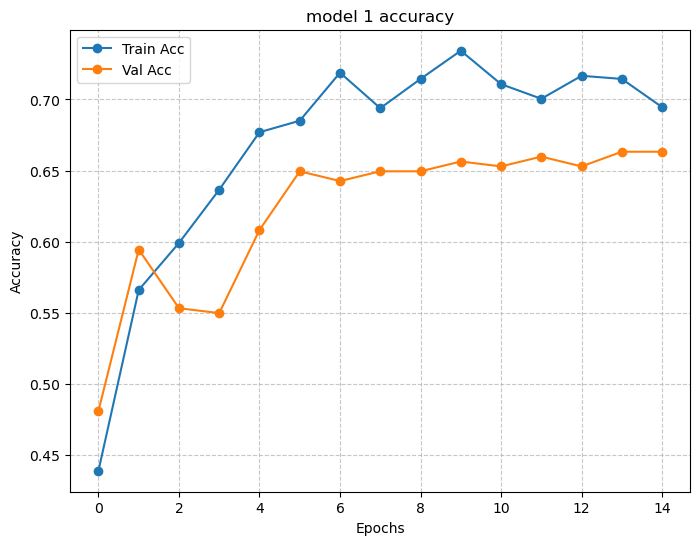

In [36]:
plt.figure(figsize=(8, 6))
plt.plot(train_accs, label='Train Acc', marker='o')
plt.plot(val_accs, label='Val Acc', marker='o')
plt.title('model 1 accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

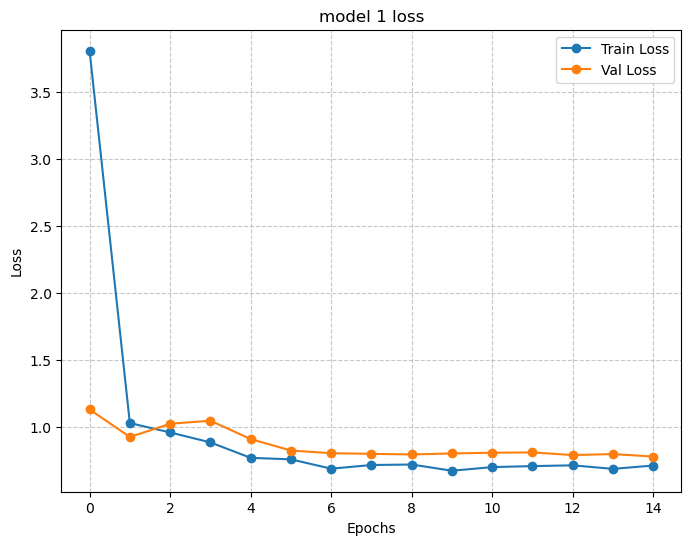

In [37]:
plt.figure(figsize=(8, 6))
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(val_losses, label='Val Loss', marker='o')
plt.title('model 1 loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

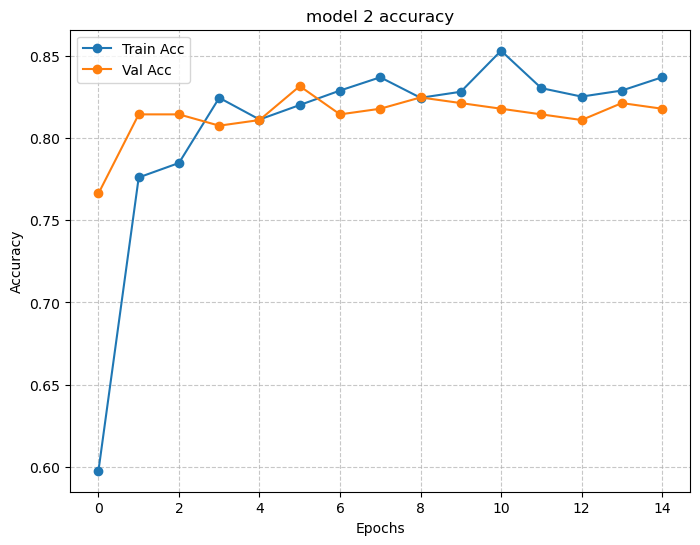

In [38]:
plt.figure(figsize=(8, 6))
plt.plot(train_accs_m2, label='Train Acc', marker='o')
plt.plot(val_accs_m2, label='Val Acc', marker='o')
plt.title('model 2 accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

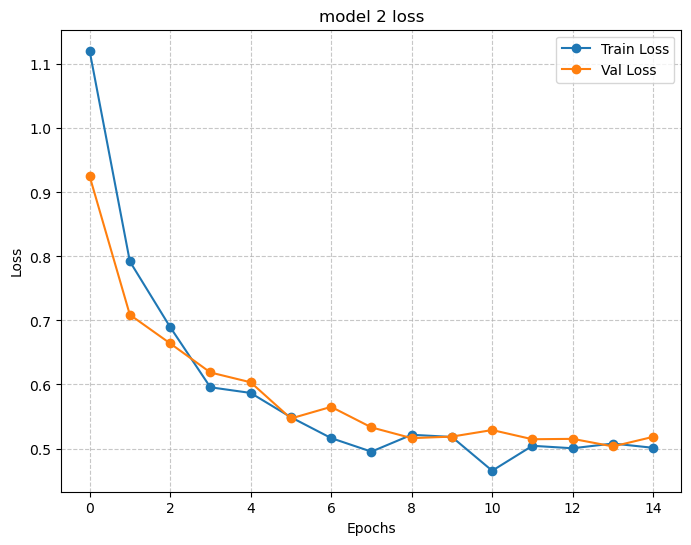

In [39]:
plt.figure(figsize=(8, 6))
plt.plot(train_losses_m2, label='Train Loss', marker='o')
plt.plot(val_losses_m2, label='Val Loss', marker='o')
plt.title('model 2 loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
def eval_model(model, test_loader, model_name):
    model.eval()
    y_true = []
    y_pred = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)            
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())
            
    print(f"Classification Report {model_name}")
    print(classification_report(y_true, y_pred, target_names=data_raw.classes, zero_division=0))

eval_model(model_scratch, test_loader, "Model 1")
eval_model(model2, test_loader, "Model 2")

Classification Report Model 1
                precision    recall  f1-score   support

    Earthquake       0.15      0.60      0.24         5
    Land_Slide       0.46      0.35      0.40        66
    Urban_Fire       0.73      0.79      0.76        66
Water_Disaster       0.80      0.78      0.79       156

      accuracy                           0.68       293
     macro avg       0.54      0.63      0.55       293
  weighted avg       0.70      0.68      0.69       293

Classification Report Model 2
                precision    recall  f1-score   support

    Earthquake       0.31      0.80      0.44         5
    Land_Slide       0.74      0.74      0.74        66
    Urban_Fire       0.92      0.89      0.91        66
Water_Disaster       0.93      0.89      0.91       156

      accuracy                           0.86       293
     macro avg       0.72      0.83      0.75       293
  weighted avg       0.87      0.86      0.86       293

